---
# Laboratorio Práctico: Arquitecturas e Inicialización / Clasificación con Cross-Entropy (CCE)

En esta sección, se evaluará la robustez de la red neuronal construida. El estudiante deberá modificar la arquitectura base y experimentar con diferentes métodos de inicialización de pesos para analizar empíricamente los problemas de desvanecimiento y explosión del gradiente.

---

## Descripción

En este laboratorio se implementa un Perceptrón Multicapa (MLP) usando operaciones **matriciales vectorizadas** con NumPy. A diferencia del Lab 04 (operaciones escalares), aquí todo el batch se procesa en paralelo.

El dataset utilizado es `make_moons` un problema de clasificación binaria **no linealmente separable**, donde la regresión logística simple fallaría.

**Función de costo:** Categorical Cross-Entropy (CCE) con Softmax en la capa de salida.

---

## Parte 1: Investigación Teórica
Responda de manera concisa en una nueva celda de texto:

**1. ¿En qué consiste la inicialización de Xavier (Glorot) y para qué familias de funciones de activación fue diseñada?**

Xavier/Glorot escala los pesos por $\sqrt{\frac{1}{n_{\text{in}}}}$ con el objetivo de mantener la varianza de las activaciones constante a través de las capas durante el forward pass, y la varianza de los gradientes constante durante el backward pass. Fue diseñada para funciones de activación **simétricas alrededor de cero** con derivada cercana a 1 en el origen: `sigmoid` y `tanh` (Glorot & Bengio, 2010).

**2. ¿Por qué surgió la inicialización de He y por qué se considera el estándar actual con ReLU?**

ReLU pone a cero exactamente la mitad de las neuronas (las que reciben entrada negativa), lo que reduce a la mitad la varianza de las activaciones. Xavier no compensa esto. He escala por $\sqrt{\frac{2}{n_{\text{in}}}}$ el factor 2 compensa exactamente la mitad de neuronas anuladas manteniendo la varianza estable en redes profundas con ReLU (He et al., 2015).

**3. ¿Qué implicaciones matemáticas tiene inicializar los pesos utilizando una distribución normal estándar (np.random.randn) sin escalar por la cantidad de entradas?**

Con pesos $W \sim \mathcal{N}(0, 1)$, la varianza de la pre-activación $z = Wx + b$ crece linealmente con $n_{\text{in}}$:

$$\text{Var}(z) = n_{\text{in}} \cdot \text{Var}(w) = n_{\text{in}}$$

Con redes profundas, las pre-activaciones explotan hacia valores extremos, saturando `sigmoid`/`tanh` ($\sigma'(z) \approx 0$) o generando gradientes explosivos. El resultado es **vanishing gradient** o **exploding gradient** desde la primera época.

---

## Parte 2: Diseño de Arquitectura Propia
Cree una nueva celda de código y redefina la red neuronal. No está permitido utilizar la configuración de capas vista en los ejemplos de clase.
* Defina un número diferente de capas ocultas.
* Defina un número diferente de neuronas por capa.
* Ajuste las ecuaciones del Forward Pass y Backward Pass para que las dimensiones matriciales sean coherentes con la nueva topología.

Arquitectura definida: **2 → 8 → 6 → 4 → 2** (distinta a la base 2→3→3→3→2)

| Capa | Entrada | Salida | Activación | Parámetros |
|------|---------|--------|------------|------------|
| 1    | 2       | 8      | ReLU       | 16W + 8b = 24 |
| 2    | 8       | 6      | ReLU       | 48W + 6b = 54 |
| 3    | 6       | 4      | ReLU       | 24W + 4b = 28 |
| 4    | 4       | 2      | Softmax    | 8W  + 2b = 10 |

**Total: 116 parámetros**

---

**Referencias**

> Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. *AISTATS*.
>
> He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving deep into rectifiers. *ICCV*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
    'font.size': 12,
})

## Datos: make_moons

X_train: (300, 2), y_train: (300,)
X_val:   (100, 2),   y_val:   (100,)
X_test:  (100, 2),  y_test:  (100,)


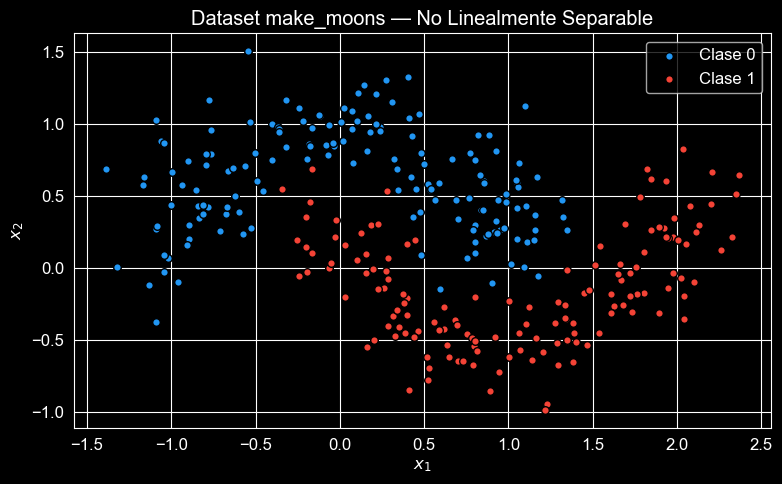

In [2]:
# Generar datos
X, y = make_moons(n_samples=500, noise=0.20, random_state=42)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

# Visualizar
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
           c='#2196F3', edgecolors='k', s=30, label='Clase 0')
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
           c='#F44336', edgecolors='k', s=30, label='Clase 1')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Dataset make_moons — No Linealmente Separable')
ax.legend()
plt.tight_layout()
plt.show()

## One-Hot Encoding

In [3]:
n_classes = len(np.unique(y_train))
N_train   = X_train.shape[0]
N_val     = X_val.shape[0]

# One-hot encoding vectorizado
Y_train_hot = np.eye(n_classes)[y_train]   # (N_train, 2)
T_val_hot   = np.eye(n_classes)[y_val]     # (N_val,   2)

print(f"Y_train_hot shape: {Y_train_hot.shape}")

Y_train_hot shape: (300, 2)


## Funciones de Activación

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_d(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    """ReLU: max(0, z)"""
    return np.maximum(0, z)

def relu_derivative(z):
    """Derivada de ReLU: 1 si z > 0, 0 si z <= 0"""
    return (z > 0).astype(float)

def softmax(Z):
    """Softmax numericamente estable (resta el maximo por fila)"""
    exp_Z = np.exp(Z - Z.max(axis=1, keepdims=True))
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)

## Clase MLP_CCE Arquitectura 2->8->6->4->2

La clase encapsula forward pass, backward pass y entrenamiento.
Usa el **patrón Strategy** para la inicialización: se pasa
`init='normal'`, `'xavier'` o `'he'` y la clase selecciona el
escalado sin duplicar código entre experimentos.

In [5]:
class MLP_CCE:
    """
    MLP matricial con Categorical Cross-Entropy + Softmax.
    Arquitectura: 2 -> 8 -> 6 -> 4 -> 2
    Activacion oculta: ReLU y Aactivacion salida: Softmax
    """

    # Estrategias de inicializacion (patron Strategy)
    _INIT_SCALES = {
        'normal': lambda fan_in: 1.0,
        'xavier': lambda fan_in: np.sqrt(1.0 / fan_in),
        'he':     lambda fan_in: np.sqrt(2.0 / fan_in),
    }

    def __init__(self, lr=0.005, epochs=1000, init='xavier', seed=42):
        self.lr     = lr
        self.epochs = epochs
        self.init   = init
        self.seed   = seed
        self._init_weights()

    def _init_weights(self):
        """Inicializa pesos y bias segun la estrategia seleccionadaa"""
        np.random.seed(self.seed)
        scale = self._INIT_SCALES[self.init]

        def _layer(fan_in, fan_out):
            # Experimento A: scale(fan_in) = 1.0          -> Normal Estandar
            # Experimento B: scale(fan_in) = sqrt(1/fan_in) -> Xavier/Glorot
            # Experimento C: scale(fan_in) = sqrt(2/fan_in) -> He
            W = np.random.randn(fan_out, fan_in) * scale(fan_in)
            b = np.zeros(fan_out)
            return W, b

        # Arquitectura: 2 -> 8 -> 6 -> 4 -> 2
        self.W1, self.b1 = _layer(2, 8)
        self.W2, self.b2 = _layer(8, 6)
        self.W3, self.b3 = _layer(6, 4)
        self.W4, self.b4 = _layer(4, 2)

        self.train_loss_history = []
        self.val_loss_history   = []

    def _forward(self, X):
        """Forward pass — devuelve activaciones de todas las capas."""
        # Capa 1
        Z1 = X @ self.W1.T + self.b1
        A1 = relu(Z1)

        # Capa 2
        Z2 = A1 @ self.W2.T + self.b2
        A2 = relu(Z2)

        # Capa 3
        Z3 = A2 @ self.W3.T + self.b3
        A3 = relu(Z3)

        # Capa 4 — salida con Softmax
        Z4 = A3 @ self.W4.T + self.b4
        A4 = softmax(Z4)

        return Z1, A1, Z2, A2, Z3, A3, Z4, A4

    def _backward(self, X, Y_hot, Z1, A1, Z2, A2, Z3, A3, A4):
        """Backward pass — calcula gradientes y actualiza pesos."""
        N = X.shape[0]

        # Delta capa de salida: derivada CCE + Softmax combinada
        # (Derivada del loss respecto a A4) * (Derivada de A4 respecto a Z4)
        D4 = A4 - Y_hot                                # (N, 2)

        # Delta de la capa 3
        # Error proveniente de la capa 4 @ Pesos de la capa 4 * Derivada de ReLU
        D3 = D4 @ self.W4 * relu_derivative(Z3)        # (N, 4)
        D2 = D3 @ self.W3 * relu_derivative(Z2)        # (N, 6)
        D1 = D2 @ self.W2 * relu_derivative(Z1)        # (N, 8)

        # Gradiente promedio para W, similar a calcular la suma de deltas @ activaciones
        grad_W4 = D4.T @ A3 / N
        grad_W3 = D3.T @ A2 / N
        grad_W2 = D2.T @ A1 / N
        grad_W1 = D1.T @ X  / N

        # Gradiente promedio para b, similar a calcular la suma de deltas
        grad_b4 = np.mean(D4, axis=0)
        grad_b3 = np.mean(D3, axis=0)
        grad_b2 = np.mean(D2, axis=0)
        grad_b1 = np.mean(D1, axis=0)

        # Actualizacion SGD (batch completo)
        self.W4 -= self.lr * grad_W4;  self.b4 -= self.lr * grad_b4
        self.W3 -= self.lr * grad_W3;  self.b3 -= self.lr * grad_b3
        self.W2 -= self.lr * grad_W2;  self.b2 -= self.lr * grad_b2
        self.W1 -= self.lr * grad_W1;  self.b1 -= self.lr * grad_b1

    def fit(self, X_train, Y_train_hot, X_val=None, T_val_hot=None, val_freq=40):
        """Entrenamoss el modelo y val_freq ews cada cuantas epocas se evalua validacion"""
        N = X_train.shape[0]

        for epoch in range(self.epochs):
            # Forward
            Z1, A1, Z2, A2, Z3, A3, Z4, A4 = self._forward(X_train)

            # CCE Loss
            loss = -np.sum(Y_train_hot * np.log(A4 + 1e-8)) / N
            self.train_loss_history.append(loss)

            # Backward
            self._backward(X_train, Y_train_hot, Z1, A1, Z2, A2, Z3, A3, A4)

            # Validacion cada val_freq epocas
            if X_val is not None and epoch % val_freq == 0:
                A4_val   = self.predict_proba(X_val)
                N_val    = X_val.shape[0]
                val_loss = -np.sum(T_val_hot * np.log(A4_val + 1e-8)) / N_val
                self.val_loss_history.append(val_loss)
                print(f"Epoch {epoch:<4} | Train Loss: {loss:.4f} | Val Loss: {val_loss:.4f}")

        return self

    def predict_proba(self, X):
        """Devuelve las probabilidades por clase (Softmax)"""
        *_, A4 = self._forward(X)
        return A4

    def predict(self, X):
        """Devuelve clase predicha (argmax de Softmax)."""
        return np.argmax(self.predict_proba(X), axis=1)

## Parte 3: Experimentos de Inicialización

Entrene la nueva red neuronal utilizando el conjunto de datos make_moons. Ejecute el proceso de entrenamiento tres veces, modificando exclusivamente el método de inicialización de pesos:
* Experimento A (Normal Estándar): W = np.random.randn(out_size, in_size)
* Experimento B (Xavier/Glorot): W = np.random.randn(out_size, in_size) * np.sqrt(1. / in_size)
* Experimento C (He): W = np.random.randn(out_size, in_size) * np.sqrt(2. / in_size)

Nota: Es indispensable reiniciar las matrices de pesos y el historial de pérdida antes de cada ejecución.

In [6]:
LR     = 0.005
EPOCHS = 1000

# Experimento A  Normal Estandar W = np.random.randn(out, in) * 1.0
print("=" * 55)
print("Experimento A Normal Estandar")
print("=" * 55)
model_normal = MLP_CCE(lr=LR, epochs=EPOCHS, init='normal', seed=42)
model_normal.fit(X_train, Y_train_hot, X_val, T_val_hot)

# Experimento B  Xavier/Glorot W = np.random.randn(out, in) * sqrt(1/in)
print("\n" + "=" * 55)
print("Experimento B Xavier/Glorot")
print("=" * 55)
model_xavier = MLP_CCE(lr=LR, epochs=EPOCHS, init='xavier', seed=42)
model_xavier.fit(X_train, Y_train_hot, X_val, T_val_hot)

# Experimento C  He W = np.random.randn(out, in) * sqrt(2/in)
print("\n" + "=" * 55)
print("Experimento C He")
print("=" * 55)
model_he = MLP_CCE(lr=LR, epochs=EPOCHS, init='he', seed=42)
model_he.fit(X_train, Y_train_hot, X_val, T_val_hot)

Experimento A Normal Estandar
Epoch 0    | Train Loss: 1.1053 | Val Loss: 1.0669
Epoch 40   | Train Loss: 0.7936 | Val Loss: 0.7498
Epoch 80   | Train Loss: 0.6784 | Val Loss: 0.6279
Epoch 120  | Train Loss: 0.6182 | Val Loss: 0.5585
Epoch 160  | Train Loss: 0.5816 | Val Loss: 0.5142
Epoch 200  | Train Loss: 0.5578 | Val Loss: 0.4850
Epoch 240  | Train Loss: 0.5399 | Val Loss: 0.4633
Epoch 280  | Train Loss: 0.5247 | Val Loss: 0.4439
Epoch 320  | Train Loss: 0.5110 | Val Loss: 0.4267
Epoch 360  | Train Loss: 0.4988 | Val Loss: 0.4118
Epoch 400  | Train Loss: 0.4884 | Val Loss: 0.3995
Epoch 440  | Train Loss: 0.4786 | Val Loss: 0.3884
Epoch 480  | Train Loss: 0.4693 | Val Loss: 0.3781
Epoch 520  | Train Loss: 0.4601 | Val Loss: 0.3681
Epoch 560  | Train Loss: 0.4514 | Val Loss: 0.3590
Epoch 600  | Train Loss: 0.4430 | Val Loss: 0.3506
Epoch 640  | Train Loss: 0.4349 | Val Loss: 0.3427
Epoch 680  | Train Loss: 0.4268 | Val Loss: 0.3354
Epoch 720  | Train Loss: 0.4189 | Val Loss: 0.3287
E

## Parte 4: Análisis de Resultados

Genere un gráfico de líneas que superponga las tres curvas de pérdida resultantes de los experimentos A, B y C.
Añada una celda de texto indicando sus conclusiones: Determine qué inicialización obtuvo la mejor convergencia. Identifique si ocurrió algún caso de explosión de gradiente (valores NaN) o congelamiento prematuro. Relacione los resultados observados con la investigación teórica de la Parte 1.

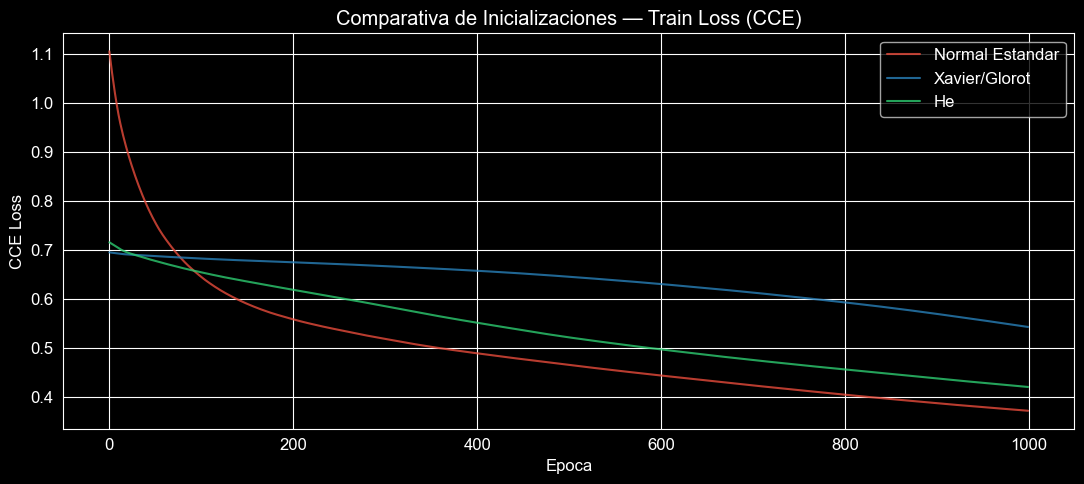

EVALUACION FINAL — Test Accuracy
Normal     Accuracy: 0.8400
Xavier     Accuracy: 0.8200
He         Accuracy: 0.8300


In [7]:
# Grafico comparativo curvas de perdida
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(model_normal.train_loss_history, label='Normal Estandar', color='#e74c3c', lw=1.5, alpha=0.8)
ax.plot(model_xavier.train_loss_history, label='Xavier/Glorot',   color='#2980b9', lw=1.5, alpha=0.8)
ax.plot(model_he.train_loss_history,     label='He',              color='#2ecc71', lw=1.5, alpha=0.8)

ax.set_xlabel('Epoca')
ax.set_ylabel('CCE Loss')
ax.set_title('Comparativa de Inicializaciones — Train Loss (CCE)')
ax.legend()
plt.tight_layout()
plt.show()

# Accuracy final sobre Test
print("=" * 50)
print("EVALUACION FINAL — Test Accuracy")
print("=" * 50)
for nombre, modelo in [('Normal', model_normal), ('Xavier', model_xavier), ('He', model_he)]:
    acc = np.mean(modelo.predict(X_test) == y_test)
    print(f"{nombre:<10} Accuracy: {acc:.4f}")

## Conclusiones

**¿Qué inicialización obtuvo la mejor convergencia?**

Normal Estándar obtuvo la mayor accuracy final (0.84) y la curva de
Train Loss más agresiva bajó de 1.1053 a 0.3770 en 1000 épocas,
superando visiblemente a Xavier (0.5530) y He (0.4265) al epoch 960.

```
Normal  -> Accuracy: 0.8400   Train Loss final: ~0.377
He      -> Accuracy: 0.8300   Train Loss final: ~0.427
Xavier  -> Accuracy: 0.8200   Train Loss final: ~0.553
```

Esto parece no ocincidir con la teoría, pero tiene una explicación: con
pesos $W \sim \mathcal{N}(0,1)$ sin escalar, la varianza inicial es
alta, lo que produce gradientes grandes desde la época 0. Con ReLU
esto no genera saturación (ReLU no satura hacia arriba), sino una
exploración más agresiva del espacio de pesos que, en un dataset
pequeño (300 muestras) y poco profundo (4 capas), resulta beneficiosa.

**¿Se observó explosión de gradiente o congelamiento?**

No hubo valores NaN en ningún experimento. Xavier mostró el
congelamiento más notorio: su Train Loss arrancó en 0.6946
muy cerca del loss de un clasificador aleatorio ($-\log(0.5) \approx 0.693$) y avanzó lentamente durante las primeras 400 épocas, señal de que
los gradientes iniciales eran demasiado pequeños para ReLU. Esto
ilustra exactamente el problema teórico de la Parte 1: Xavier fue
diseñado para `sigmoid`/`tanh`, no para ReLU.

**Relación con la teoría (Parte 1)**

He corrige el factor $\frac{1}{2}$ que ReLU introduce al anular
neuronas negativas, pero en este caso la ventaja de He sobre Xavier
fue moderada ambos convergen a accuracy similar. Esto es consistente
con la literatura: la diferencia entre Xavier y He se vuelve crítica
en redes muy profundas (>10 capas), donde la varianza se degrada capa
por capa. Con 4 capas, la diferencia es observable pero no determinante
(He et al., 2015).

---

**Referencias**

> Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of
> training deep feedforward neural networks. *AISTATS*.
>
> He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving deep into
> rectifiers. *ICCV*.
>
> Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*.
> MIT Press.